# Spotter Freight Rate Prediction — Final Solution

This notebook is the cleaned, final version for the Spotter.AI Machine Learning Engineer assessment.

It:
1. loads and checks the supplied data,
2. cleans invalid values without target leakage,
3. engineers calendar and route features,
4. evaluates a model using a **time-based holdout**,
5. trains the final model on all labelled development data,
6. creates the required 12,000 validation predictions,
7. creates the required 31 December 2025 predictions, and
8. runs the provided scorer.

### Important December design decision
The December chart input contains only seven columns and does **not** contain `market_index`, `quote_signal`, or coordinates. Therefore, the December forecasting model uses only features that actually exist in that file. This avoids fabricating unavailable inputs. Cyclic calendar features (`sin`/`cos`) are used so December dates remain meaningful even though the labelled data ends in October.


In [19]:
#  IMPORTING ALL NECESSARY LIBRARIES

from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from catboost import CatBoostRegressor
except ImportError as exc:
    raise ImportError(
        "CatBoost is required. Run: python -m pip install catboost"
    ) from exc

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Python:", sys.version.split()[0])
print("CatBoost imported successfully.")


Python: 3.12.3
CatBoost imported successfully.


In [20]:
#  FIND PROJECT ROOT AND DATA FILES
# Works when the notebook is opened from notebooks/ or the project root.

candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

PROJECT_ROOT = next(
    (p.resolve() for p in candidates if (p / "data").is_dir()),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project root. Open this notebook inside the spotter-freight-rate project."
    )

DATA_DIR = PROJECT_ROOT / "data"

def find_file(*names):
    for name in names:
        path = DATA_DIR / name
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find any of {names} in {DATA_DIR}")

TRAIN_PATH = find_file("train-test.csv", "train_test.csv")
VALIDATION_PATH = find_file("validation.csv")
TEMPLATE_PATH = find_file(
    "validation-predictions-template.csv",
    "validation_predictions_template.csv",
)
DECEMBER_PATH = find_file(
    "december-chart-inputs.csv",
    "december_chart_inputs.csv",
)
SCORE_PATH = PROJECT_ROOT / "score.py"

print("Project root:", PROJECT_ROOT)
print("Training:", TRAIN_PATH)
print("Validation:", VALIDATION_PATH)
print("December:", DECEMBER_PATH)


Project root: /home/shane-bonifacio-coutinho/Desktop/spotter-freight-rate
Training: /home/shane-bonifacio-coutinho/Desktop/spotter-freight-rate/data/train-test.csv
Validation: /home/shane-bonifacio-coutinho/Desktop/spotter-freight-rate/data/validation.csv
December: /home/shane-bonifacio-coutinho/Desktop/spotter-freight-rate/data/december-chart-inputs.csv


In [21]:

#  LOAD DATA

df = pd.read_csv(TRAIN_PATH)
validation_data = pd.read_csv(VALIDATION_PATH)
template = pd.read_csv(TEMPLATE_PATH)
december_data = pd.read_csv(DECEMBER_PATH)

print("Development data:", df.shape)
print("Validation data:", validation_data.shape)
print("December data:", december_data.shape)
print("Template:", template.shape)

display(df.head())


Development data: (48000, 14)
Validation data: (12000, 13)
December data: (31, 7)
Template: (12000, 2)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [22]:

#  DATA QUALITY CHECKS
# (CHECKING FOR MISSING VALUES, DUPLICATES, AND DATE RANGE)

print("Development columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate load IDs:", df["load_id"].duplicated().sum())

print("\nDate range:")
print(pd.to_datetime(df["date"], errors="coerce").min(),
      "to",
      pd.to_datetime(df["date"], errors="coerce").max())

print("\nTarget summary:")
display(df["posted_rate"].describe())

print("\nDecember columns:")
print(december_data.columns.tolist())


Development columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Missing values:


market_index    374
weight          300
delivery          0
pickup_lat        0
load_id           0
pickup            0
delivery_lat      0
pickup_lon        0
distance          0
delivery_lon      0
equipment         0
date              0
quote_signal      0
posted_rate       0
dtype: int64

Duplicate rows: 0
Duplicate load IDs: 0

Date range:
2025-01-01 00:00:00 to 2025-10-31 00:00:00

Target summary:


count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


December columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [23]:

#  CLEANING DEVELOPMENT DATA

df_clean = df.copy()

df_clean["date"] = pd.to_datetime(df_clean["date"], errors="coerce")

# Negative weights are invalid; keep the row and let model preprocessing
# impute the missing weight rather than deleting useful labelled data.
df_clean.loc[
    pd.to_numeric(df_clean["weight"], errors="coerce") < 0,
    "weight"
] = np.nan


# Target and date are required.
df_clean = df_clean.dropna(subset=["posted_rate", "date"]).copy()

print("Rows after cleaning:", len(df_clean))
print("Missing weights:", df_clean["weight"].isna().sum())
print("Invalid/negative weights remaining:",
      (pd.to_numeric(df_clean["weight"], errors="coerce") < 0).sum())


Rows after cleaning: 48000
Missing weights: 592
Invalid/negative weights remaining: 0


## FEATURE ENGINEERING

`posted_rate` is the target, so features derived from it (such as `rate_per_mile`) are excluded to prevent target leakage.

Calendar variables are created from `date`. In addition to ordinary calendar fields, cyclic encodings are used:

- `doy_sin`, `doy_cos` represent position in the annual cycle.
- `dow_sin`, `dow_cos` represent position in the weekly cycle.

This is important for December because the development labels stop at October; a tree model using only raw `day_of_year` cannot extrapolate beyond its observed range reliably.


In [24]:

#  FEATURE ENGINEERING

def add_features(dataframe):
    data = dataframe.copy()
    data["date"] = pd.to_datetime(data["date"], errors="coerce")

    doy = data["date"].dt.dayofyear
    dow = data["date"].dt.dayofweek

    data["year"] = data["date"].dt.year.astype(float)
    data["month"] = data["date"].dt.month.astype(float)
    data["day_of_month"] = data["date"].dt.day.astype(float)
    data["day_of_week"] = dow.astype(float)
    data["day_of_year"] = doy.astype(float)

    data["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    data["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    data["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    data["dow_cos"] = np.cos(2 * np.pi * dow / 7)

    data["route"] = (
        data["pickup"].astype(str)
        + " -> "
        + data["delivery"].astype(str)
    )

    if {"pickup_lat", "delivery_lat"}.issubset(data.columns):
        data["lat_diff"] = data["delivery_lat"] - data["pickup_lat"]

    if {"pickup_lon", "delivery_lon"}.issubset(data.columns):
        data["lon_diff"] = data["delivery_lon"] - data["pickup_lon"]

    return data


train_f = add_features(df_clean)
validation_f = add_features(validation_data)
december_f = add_features(december_data)

categorical_features = ["pickup", "delivery", "equipment", "route"]

calendar_numeric = [
    "year", "month", "day_of_month", "day_of_week", "day_of_year",
    "doy_sin", "doy_cos", "dow_sin", "dow_cos"
]

common_numeric_features = [
    "distance", "weight"
] + calendar_numeric

full_numeric_features = [
    "distance", "weight",
    "market_index", "quote_signal",
    "pickup_lat", "pickup_lon",
    "delivery_lat", "delivery_lon",
    "lat_diff", "lon_diff",
] + calendar_numeric

full_features = categorical_features + full_numeric_features
december_features = categorical_features + common_numeric_features

# CatBoost handles missing numerical values natively.
for frame in [train_f, validation_f, december_f]:
    for col in categorical_features:
        if col in frame.columns:
            frame[col] = frame[col].fillna("Missing").astype(str)

print("Full model features:", len(full_features))
print(full_features)
print("\nDecember-compatible features:", len(december_features))
print(december_features)


Full model features: 23
['pickup', 'delivery', 'equipment', 'route', 'distance', 'weight', 'market_index', 'quote_signal', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'lat_diff', 'lon_diff', 'year', 'month', 'day_of_month', 'day_of_week', 'day_of_year', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos']

December-compatible features: 15
['pickup', 'delivery', 'equipment', 'route', 'distance', 'weight', 'year', 'month', 'day_of_month', 'day_of_week', 'day_of_year', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos']


Equipment:


equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


Target by month:


,mean,median,count
month,,,
1,2255.97,1915.20,4918
2,2273.80,1994.25,4337
3,2372.27,2022.92,5036
4,2372.16,2044.24,4819
5,2421.78,2065.51,4913
6,2497.03,2120.22,4783
7,2415.16,2059.14,4912
8,2338.41,2015.73,4759
9,2406.37,2057.13,4670


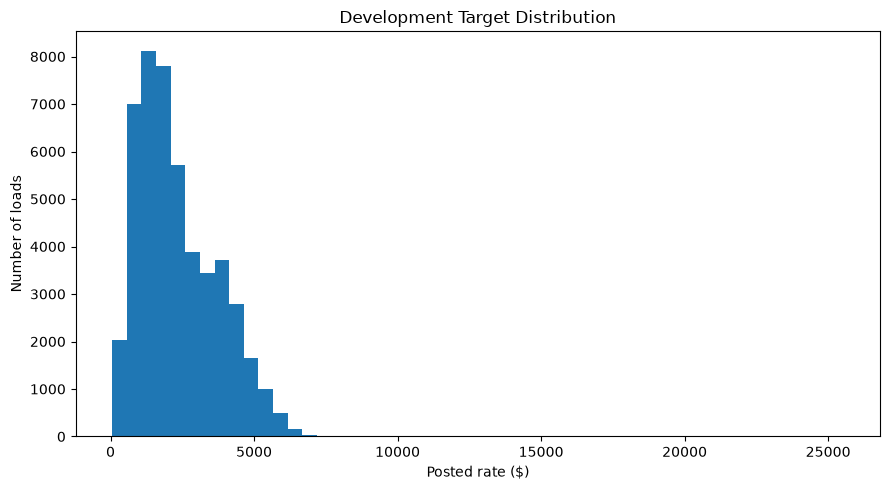

In [25]:

#  EDA

print("Equipment:")
display(df_clean["equipment"].value_counts())

print("\nTarget by month:")
monthly = (
    df_clean.assign(month=df_clean["date"].dt.month)
    .groupby("month")["posted_rate"]
    .agg(["mean", "median", "count"])
)
display(monthly.round(2))

plt.figure(figsize=(9, 5))
plt.hist(df_clean["posted_rate"], bins=50)
plt.xlabel("Posted rate ($)")
plt.ylabel("Number of loads")
plt.title("Development Target Distribution")
plt.tight_layout()
plt.show()


## TIME BASED VALIDATION

The supplied labelled data runs from January through October 2025, while the supplied validation data is later in time (November–December). A random split would mix future-like and past observations.

We therefore hold out **September–October 2025** and train on January–August 2025. This better simulates the real forecasting task.


In [26]:

#  TIME-BASED HOLDOUT

cutoff = pd.Timestamp("2025-09-01")

train_mask = train_f["date"] < cutoff
holdout_mask = train_f["date"] >= cutoff

X_train = train_f.loc[train_mask, full_features]
y_train = train_f.loc[train_mask, "posted_rate"].astype(float)

X_holdout = train_f.loc[holdout_mask, full_features]
y_holdout = train_f.loc[holdout_mask, "posted_rate"].astype(float)

cat_indices = [full_features.index(c) for c in categorical_features]

print("Training period:", train_f.loc[train_mask, "date"].min(),
      "to", train_f.loc[train_mask, "date"].max())
print("Holdout period:", train_f.loc[holdout_mask, "date"].min(),
      "to", train_f.loc[holdout_mask, "date"].max())
print("Training rows:", len(X_train))
print("Holdout rows:", len(X_holdout))


Training period: 2025-01-01 00:00:00 to 2025-08-31 00:00:00
Holdout period: 2025-09-01 00:00:00 to 2025-10-31 00:00:00
Training rows: 38477
Holdout rows: 9523


In [27]:

#  EVALUATING CATBOOST ALGORITHM

evaluation_model = CatBoostRegressor(
    iterations=700,
    depth=8,
    learning_rate=0.05,
    loss_function="MAE",
    eval_metric="MAE",
    l2_leaf_reg=5,
    random_seed=RANDOM_STATE,
    verbose=False,
)

evaluation_model.fit(
    X_train,
    y_train,
    cat_features=cat_indices,
)

holdout_pred = np.maximum(
    evaluation_model.predict(X_holdout),
    0.01
)

validation_mae = mean_absolute_error(y_holdout, holdout_pred)
validation_rmse = mean_squared_error(y_holdout, holdout_pred) ** 0.5
validation_r2 = r2_score(y_holdout, holdout_pred)

print(f"Holdout MAE:  ${validation_mae:,.2f}")
print(f"Holdout RMSE: ${validation_rmse:,.2f}")
print(f"Holdout R²:   {validation_r2:.4f}")


Holdout MAE:  $124.40
Holdout RMSE: $638.59
Holdout R²:   0.8249


Worst 20 holdout errors:


,load_id,pickup,delivery,equipment,distance,weight,date,actual,predicted,absolute_error
40096,TR-040097,Baltimore,Oklahoma City,Reefer,1760.3,29521.0,2025-09-11,20132.37,3851.250640,16281.119360
40171,TR-040172,Montgomery,Fresno,Dry Van,2283.4,32447.0,2025-09-11,20361.89,4278.098380,16083.791620
43539,TR-043540,Milwaukee,Bakersfield,Dry Van,1893.0,30760.0,2025-10-03,17514.11,3602.517438,13911.592562
46213,TR-046214,Columbia,Tucson,Flatbed,2023.4,34710.0,2025-10-20,17893.17,4123.994276,13769.175724
47298,TR-047299,Boston,Bakersfield,Reefer,2979.1,30585.0,2025-10-27,19110.30,5985.619586,13124.680414
40322,TR-040323,Montgomery,El Paso,Dry Van,1639.9,38363.0,2025-09-12,14949.25,3219.143447,11730.106553
46516,TR-046517,Toledo,Albuquerque,Reefer,1684.3,31536.0,2025-10-22,14784.38,3522.162608,11262.217392
42881,TR-042882,San Antonio,Detroit,Dry Van,1460.5,43567.0,2025-09-29,13503.63,2885.472094,10618.157906
47536,TR-047537,Los Angeles,Richmond,Dry Van,2782.4,25730.0,2025-10-29,15003.55,4733.151716,10270.398284
42149,TR-042150,Grand Rapids,Lubbock,Dry Van,1415.5,35333.0,2025-09-24,13026.22,2804.193229,10222.026771


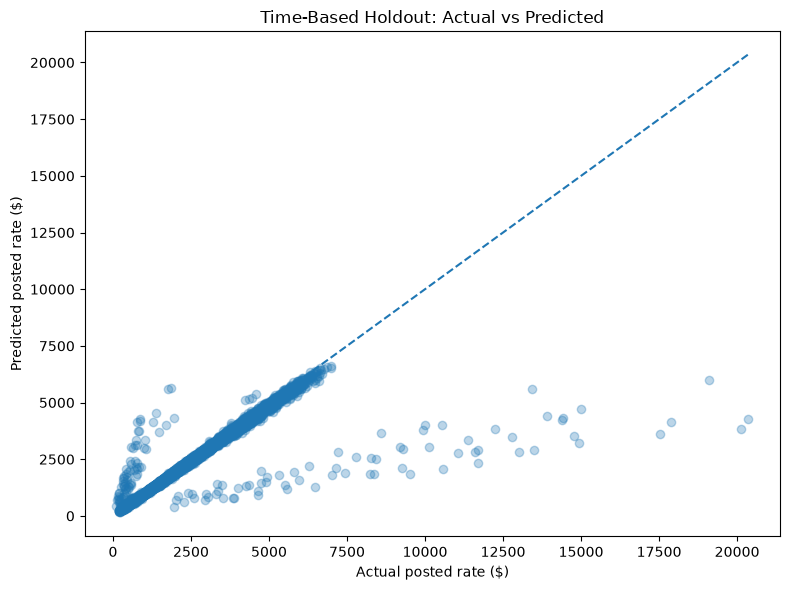

,feature,importance
4,distance,83.538950
2,equipment,3.861823
7,quote_signal,2.044030
5,weight,1.296021
1,delivery,1.168193
10,delivery_lat,1.073454
13,lon_diff,1.068419
6,market_index,0.958047
9,pickup_lon,0.925908
8,pickup_lat,0.819212


In [ ]:

#  HOLDOUT DIAGNOSTICS + FEATURE IMPORTANCE
diagnostics = train_f.loc[holdout_mask, [
    "load_id", "pickup", "delivery", "equipment", "distance", "weight", "date"
]].copy()
diagnostics["actual"] = y_holdout.to_numpy()
diagnostics["predicted"] = holdout_pred
diagnostics["absolute_error"] = (
    diagnostics["actual"] - diagnostics["predicted"]
).abs()

print("Worst 20 holdout errors:")
display(diagnostics.sort_values("absolute_error", ascending=False).head(20))

plt.figure(figsize=(8, 6))
plt.scatter(y_holdout, holdout_pred, alpha=0.3)
lo = min(y_holdout.min(), holdout_pred.min())
hi = max(y_holdout.max(), holdout_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("Actual posted rate ($)")
plt.ylabel("Predicted posted rate ($)")
plt.title("Time-Based Holdout: Actual vs Predicted")
plt.tight_layout()
plt.show()

importance = pd.DataFrame({
    "feature": full_features,
    "importance": evaluation_model.get_feature_importance()
}).sort_values("importance", ascending=False)

display(importance.head(20))


## FINAL MODEL

The holdout was used only to evaluate the modelling approach. The final validation model is now retrained on **all January–October labelled data**.

For the 12,000-load validation set we use every feature that is supplied there.

For December, the input schema is different, so a second CatBoost model is trained using only fields actually supplied in December. This is safer than inventing `market_index`, `quote_signal`, or coordinate values.


In [ ]:

#  FINAL MODEL FOR THE 12,000 VALIDATION LOADS

final_model = CatBoostRegressor(
    iterations=900,
    depth=8,
    learning_rate=0.05,
    loss_function="MAE",
    l2_leaf_reg=5,
    random_seed=RANDOM_STATE,
    verbose=False,
)

final_model.fit(
    train_f[full_features],
    train_f["posted_rate"].astype(float),
    cat_features=cat_indices,
)

validation_pred = np.maximum(
    final_model.predict(validation_f[full_features]),
    0.01
)

print("Validation predictions:", len(validation_pred))
print("Range:", validation_pred.min(), "to", validation_pred.max())


Validation predictions: 12000
Range: 190.58639952138242 to 6745.363275877214


In [ ]:

#  MODEL COMPARISON
# Gradient Boosting baseline vs CatBoost

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


gb_features = [
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "route",
    "year",
    "month",
    "day_of_month",
    "day_of_week",
    "day_of_year",
    "doy_sin",
    "doy_cos",
    "dow_sin",
    "dow_cos",
]

gb_categorical = [
    "pickup",
    "delivery",
    "equipment",
    "route",
]

gb_numeric = [
    "distance",
    "weight",
    "year",
    "month",
    "day_of_month",
    "day_of_week",
    "day_of_year",
    "doy_sin",
    "doy_cos",
    "dow_sin",
    "dow_cos",
]


gb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                ))
            ]),
            gb_categorical
        ),
        (
            "numeric",
            SimpleImputer(strategy="median"),
            gb_numeric
        )
    ]
)


gb_model = Pipeline([
    ("preprocessor", gb_preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])



print("Training Gradient Boosting baseline...")

gb_model.fit(
    X_train[gb_features],
    y_train
)

print("Gradient Boosting training complete.")



gb_holdout_pred = np.maximum(
    gb_model.predict(X_holdout[gb_features]),
    0.01
)



gb_mae = mean_absolute_error(
    y_holdout,
    gb_holdout_pred
)

gb_rmse = mean_squared_error(
    y_holdout,
    gb_holdout_pred
) ** 0.5

gb_r2 = r2_score(
    y_holdout,
    gb_holdout_pred
)


comparison = pd.DataFrame({
    "Model": [
        "Gradient Boosting",
        "CatBoost"
    ],
    "MAE": [
        gb_mae,
        validation_mae
    ],
    "RMSE": [
        gb_rmse,
        validation_rmse
    ],
    "R2": [
        gb_r2,
        validation_r2
    ]
})

display(comparison)

Training Gradient Boosting baseline...
Gradient Boosting training complete.


,Model,MAE,RMSE,R2
0,Gradient Boosting,131.249738,635.931888,0.826347
1,CatBoost,124.400479,638.594773,0.824890


In [41]:

# SAVE validation_predictions.csv

if len(template) != len(validation_pred):
    raise ValueError(
        f"Template has {len(template)} rows but model produced {len(validation_pred)}."
    )

submission = template.copy()
submission["predicted_rate"] = validation_pred

if submission.columns.tolist() != ["load_id", "predicted_rate"]:
    raise ValueError("Submission columns are incorrect.")

submission_path = PROJECT_ROOT / "validation_predictions.csv"
submission.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Shape:", submission.shape)
print("Missing predictions:", submission["predicted_rate"].isna().sum())
display(submission.head())
display(submission["predicted_rate"].describe())


Saved: /home/shane-bonifacio-coutinho/Desktop/spotter-freight-rate/validation_predictions.csv
Shape: (12000, 2)
Missing predictions: 0


,load_id,predicted_rate
0,TE-000001,858.974508
1,TE-000002,5098.733128
2,TE-000003,5352.387175
3,TE-000004,4064.802524
4,TE-000005,1811.661572


count    12000.000000
mean      2351.244252
std       1369.338200
min        190.586400
25%       1247.627191
50%       2020.165177
75%       3357.036093
max       6745.363276
Name: predicted_rate, dtype: float64

In [42]:

#  DECEMBER-COMPATIBLE MODEL
# December does not contain market_index, quote_signal, or coordinates.
# Train a model whose inputs exactly match the December schema.

december_cat_indices = [
    december_features.index(c) for c in categorical_features
]

december_model = CatBoostRegressor(
    iterations=900,
    depth=8,
    learning_rate=0.05,
    loss_function="MAE",
    l2_leaf_reg=5,
    random_seed=RANDOM_STATE,
    verbose=False,
)

december_model.fit(
    train_f[december_features],
    train_f["posted_rate"].astype(float),
    cat_features=december_cat_indices,
)

december_pred = np.maximum(
    december_model.predict(december_f[december_features]),
    0.01
)

print("December predictions:", len(december_pred))
print("Unique predictions:", len(np.unique(np.round(december_pred, 8))))
print("Range:", december_pred.min(), "to", december_pred.max())


December predictions: 31
Unique predictions: 31
Range: 859.4663959994734 to 881.7989656233665


In [43]:

#  SAVE DECEMBER PREDICTIONS

december_output = december_data.copy()
december_output["predicted_rate"] = december_pred

required_december_columns = [
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "date",
    "predicted_rate",
]

december_output = december_output[required_december_columns]
december_output.to_csv(DECEMBER_PATH, index=False)

print("Saved:", DECEMBER_PATH)
display(december_output)


Saved: /home/shane-bonifacio-coutinho/Desktop/spotter-freight-rate/data/december-chart-inputs.csv


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,867.730699
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,869.054510
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,878.743363
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,880.692320
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,878.586378
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,869.265400
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,863.874948
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,869.522982
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,871.936625
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,879.986585


In [44]:

	# 15. FINAL OUTPUT CHECKS
    # Validation output

assert len(submission) == 12000
assert submission.columns.tolist() == ["load_id", "predicted_rate"]
assert submission["load_id"].notna().all()
assert submission["load_id"].is_unique
assert submission["predicted_rate"].notna().all()
assert np.isfinite(submission["predicted_rate"]).all()
assert (submission["predicted_rate"] > 0).all()

# December output\n"
check = pd.read_csv(DECEMBER_PATH)
check["date"] = pd.to_datetime(check["date"], errors="coerce")

assert check.columns.tolist() == required_december_columns
assert len(check) == 31
assert check["date"].notna().all()
assert check["date"].is_unique
assert set(check["date"]) == set(pd.date_range("2025-12-01", "2025-12-31", freq="D"))
assert check["pickup"].eq("Lexington").all()
assert check["delivery"].eq("Fort Wayne").all()
assert np.isclose(check["distance"], 360).all()
assert check["equipment"].eq("Dry Van").all()
assert np.isclose(check["weight"], 32000).all()
assert check["predicted_rate"].notna().all()
assert np.isfinite(check["predicted_rate"]).all()
assert (check["predicted_rate"] > 0).all()
print("ALL NOTEBOOK OUTPUT CHECKS PASSED.")
print("\\nDecember predictions:")
display(check[["date", "predicted_rate"]])

ALL NOTEBOOK OUTPUT CHECKS PASSED.
\nDecember predictions:


,date,predicted_rate
0,2025-12-01,867.730699
1,2025-12-02,869.054510
2,2025-12-03,878.743363
3,2025-12-04,880.692320
4,2025-12-05,878.586378
5,2025-12-06,869.265400
6,2025-12-07,863.874948
7,2025-12-08,869.522982
8,2025-12-09,871.936625
9,2025-12-10,879.986585


In [45]:

#  RUNNING SCORER.PY FILE

if not SCORE_PATH.exists():
    print("score.py not found; run it manually from the project root.")
else:
    result = subprocess.run(
        [
            sys.executable,
            str(SCORE_PATH),
            "--predictions",
            str(submission_path),
            "--december-predictions",
            str(DECEMBER_PATH),
        ],
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
    )

    print(result.stdout)
    if result.stderr:
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError("The provided scorer failed.")

    print("SCORER PASSED.")


Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.

SCORER PASSED.
